### 1-Importaciones


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LassoCV
from sklearn.metrics import (mean_squared_error,median_absolute_error,mean_absolute_percentage_error,r2_score,root_mean_squared_error)
import pickle

### 2-Carga de datos

In [79]:
df = pd.read_csv('/workspaces/Elreno23-machine-learning-python-template/data/raw/03-linear-regression-reg-demographic-health-data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


### 3-Exploración Inicial

In [80]:
null = df.isna().sum()
print(null[null > 0])
df.info()
df.describe()
df.columns

Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='object', length=108)

### 4-Limpieza incial

In [81]:
cols = df.columns.to_list()
for i in range(0, len(cols), 20):
    print(cols[i:i+20])

df = df.drop(columns=[
    "fips","STATE_FIPS","CNTY_FIPS","COUNTY_NAME","STATE_NAME","Urban_rural_code",
    "Total Population",
    "0-9","0-9 y/o % of total pop",
    "10-19 y/o % of total pop",
    "20-29","20-29 y/o % of total pop",
    "30-39","30-39 y/o % of total pop",
    "40-49","40-49 y/o % of total pop",
    "50-59","50-59 y/o % of total pop",
    "60-69","60-69 y/o % of total pop",
    "70-79","70-79 y/o % of total pop",
    "80+","80+ y/o % of total pop",
    "White-alone pop","% White-alone",
    "Black-alone pop","% Black-alone",
    "Native American/American Indian-alone pop","% NA/AI-alone",
    "Asian-alone pop","% Asian-alone",
    "Hawaiian/Pacific Islander-alone pop","% Hawaiian/PI-alone",
    "Two or more races pop","% Two or more races",
    "Obesity_Lower 95% CI","Obesity_Upper 95% CI",
    "Heart disease_Lower 95% CI","Heart disease_Upper 95% CI",
    "COPD_Lower 95% CI","COPD_Upper 95% CI",
    "diabetes_Lower 95% CI","diabetes_Upper 95% CI",
    "CKD_Lower 95% CI","CKD_Upper 95% CI",
    "CI90LBINC_2018","CI90UBINC_2018",
    "anycondition_prevalence","anycondition_number",
    "Med_HH_Income_Percent_of_State_Total_2018",
    "Internal Medicine Primary Care (2019)",
    "Family Medicine/General Practice Primary Care (2019)",
    "Total Specialist Physicians (2019)"])

df = df.drop_duplicates()
df.isna().sum().any()
df.shape

df = df.drop(columns=["Median_Household_Income_2018","POP_ESTIMATE_2018","ICU Beds_x","GQ_ESTIMATES_2018","19-Oct","R_birth_2018", "R_death_2018", "R_NATURAL_INC_2018", "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "R_NET_MIG_2018", "anycondition_Lower 95% CI", "anycondition_Upper 95% CI"])
df_int = df.select_dtypes(include="int").columns
df_float = df.select_dtypes(include="float").columns
df_object = df.select_dtypes(include="object").columns
(df[df_int] == 0).sum().head(27)
(df[df_float] == 0).sum().head(27)
df.isna().sum().any()
df.nunique().head(22)
df.nunique().tail(21)

df[df_int].describe().T
df[df_float].describe().T


['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop']
['White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018']
['R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adults with l

,count,mean,std,min,25%,50%,75%,max
Percent of adults with less than a high school diploma 2014-18,3140.0,13.410287,6.337847,1.200000,8.800000,12.100000,17.200000,66.300000
Percent of adults with a high school diploma only 2014-18,3140.0,34.285669,7.193125,5.500000,29.800000,34.600000,39.300000,55.600000
Percent of adults completing some college or associate's degree 2014-18,3140.0,30.729777,5.206136,5.800000,27.300000,30.600000,34.200000,57.300000
Percent of adults with a bachelor's degree or higher 2014-18,3140.0,21.573121,9.434320,0.000000,15.000000,19.250000,25.600000,78.500000
PCTPOVALL_2018,3140.0,15.159459,6.131874,0.000000,10.800000,14.100000,18.300000,54.000000
PCTPOV017_2018,3140.0,21.106911,8.909328,0.000000,14.500000,20.100000,26.300000,68.300000
PCTPOV517_2018,3140.0,19.882962,8.778545,0.000000,13.400000,18.800000,24.900000,66.500000
Unemployment_rate_2018,3140.0,4.131338,1.503013,0.000000,3.100000,3.900000,4.800000,19.900000
Active Physicians per 100000 Population 2018 (AAMC),3140.0,254.923567,42.291759,191.300000,227.600000,247.100000,278.800000,847.000000
Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),3140.0,226.159013,31.542980,174.800000,202.900000,223.500000,240.700000,619.000000


### Conclusiones

-Decidimos deshacernos de todas las variables que creemos no aportan valor y generan ruido ya que muchas no estan relacionadas. Mi vairbale objetivo es diabetes_prevalence

### 5-Analisis de correlacion

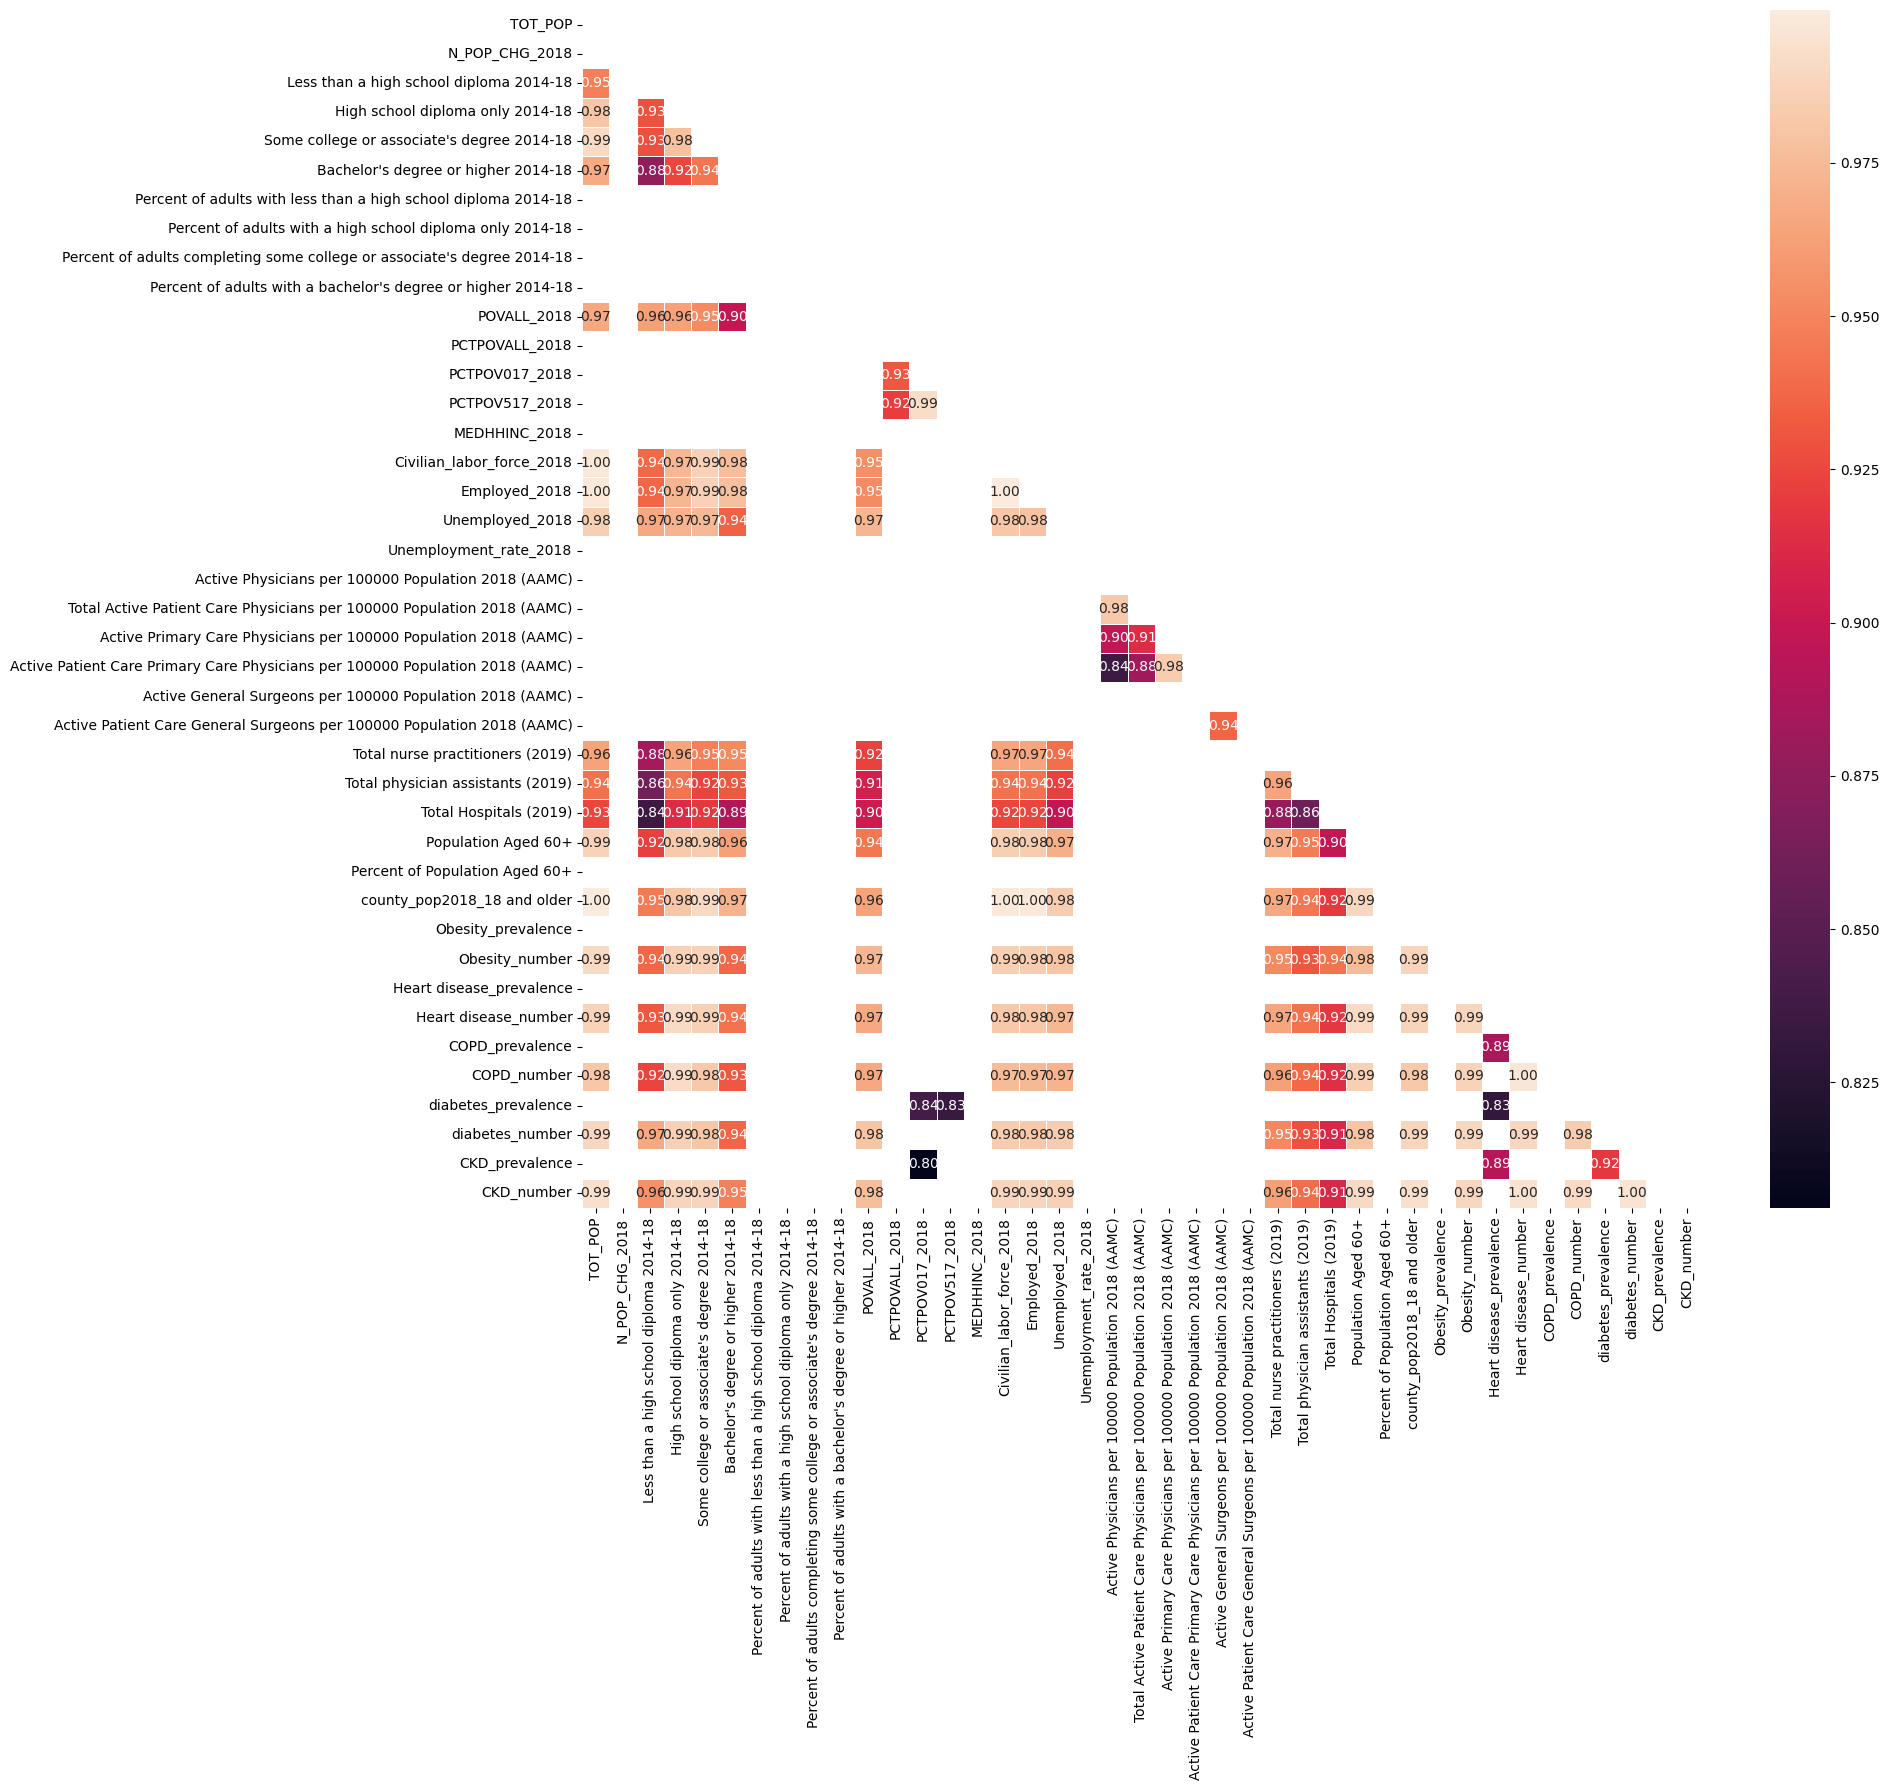

In [82]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.8]
significant_corr
fig, axis = plt.subplots(figsize=(20, 18))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

    


In [83]:
df.drop(['Obesity_number','Heart disease_number','diabetes_number','COPD_number','county_pop2018_18 and older'], axis=1, inplace=True)


### Conclusiones

Eliminamos variables que aportan la misma información pero de otra froma(conteos absolutos vs proporciones)

### 6-Dividir X e y

In [84]:
X = df.drop("diabetes_prevalence", axis=1)
y = df["diabetes_prevalence"]

### 7-Split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### 8-Escalado

In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 9-Seleccion de caracteristicas

In [87]:
selection_model = SelectKBest(f_regression,k=15)
selection_model.fit(X_train, y_train)

selected_columns = X_train.columns[selection_model.get_support()]

X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test),columns=selected_columns)
X_train_sel.head()

,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,Unemployment_rate_2018,Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,CKD_prevalence
0,14.1,35.4,18.8,15.5,23.3,21.3,50374.0,6.1,249.7,97.8,87.6,38.6,10.1,11.3,3.8
1,10.2,48.4,17.6,15.0,20.9,18.8,45761.0,4.9,273.3,100.8,88.2,33.2,9.2,9.9,3.5
2,10.8,43.8,16.1,12.2,14.8,13.3,54718.0,3.8,212.0,80.3,74.4,33.7,7.3,9.2,2.9
3,7.9,32.8,24.3,9.8,12.5,10.8,61849.0,3.3,189.1,73.9,68.5,36.5,7.8,8.1,3.0
4,8.9,36.4,21.2,17.3,27.6,25.2,48413.0,4.2,249.7,97.8,87.6,37.5,8.4,9.6,3.4


### Conclusiones

-Obtenemos las 15 mejores caracteristicas que seleccionó el modelo
-Obtenemos un array con las columnas seleccionadas(True)
-Aplicamos la seleccion de caracteristicas y obtenemos DataFrames

### 10-Modelado

In [88]:
model = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10])
model.fit(X_train_sel, y_train)
print("Mejor alpha:", model.alpha_)



Mejor alpha: 0.001


### Conclusiones

-Guiamos al modelo con un rango optimo de valores para alphas ya que si dejamos que el modelo lo haga por si solo el resultado es malo. 

### 11-Prediccion

In [89]:
y_pred_test = model.predict(X_test_sel)
y_pred_train = model.predict(X_train_sel)
y_pred_test,y_pred_train

(array([14.95399312,  9.40274854, 18.83988727, 10.90300997,  8.93552484,
         9.79935635, 11.00732715, 17.21589125, 11.521873  ,  9.22282082,
        12.06241615, 16.2391305 ,  9.02812131, 15.45271788, 10.33223171,
        13.42855733, 11.82587166, 14.68669707, 17.7872695 , 12.32246452,
        14.61679705, 12.56180589, 10.68421022, 15.12442848, 12.29943586,
        10.48583397,  8.33851242, 12.99441529, 11.21096736, 17.38106286,
        19.84288407, 17.22018794, 14.23385903, 12.6618797 , 11.26618386,
        15.40140927, 14.2882727 , 10.51730819, 12.07115357,  8.96561026,
        17.48013004,  9.92633151, 11.73934107, 11.95711835, 11.65982731,
        14.62048549, 13.83812572, 13.83847392, 16.43073517, 17.16001806,
        15.15150729, 23.57091541, 10.79214105, 16.05829646, 14.1191607 ,
        19.47432618, 10.17382836, 11.11836625, 12.961613  , 12.47758259,
         9.30566517, 13.90805853, 14.42990648, 10.40782178, 12.67307524,
        10.30875984, 11.78170709, 13.8826055 , 12.4

### Métricas

In [92]:
def get_regression_metrics(y_predict_test, y_test, y_predict_train, y_train):
    metrics_train = (r2_score(y_train, y_predict_train),
                     median_absolute_error(y_train, y_predict_train),
                     mean_absolute_percentage_error(y_train, y_predict_train) * 100,
                     mean_squared_error(y_train, y_predict_train),
                     root_mean_squared_error(y_train, y_predict_train))
    metrics_test = (r2_score(y_test, y_predict_test),
                    median_absolute_error(y_test, y_predict_test),
                    mean_absolute_percentage_error(y_test, y_predict_test) * 100,
                    mean_squared_error(y_test, y_predict_test),
                    root_mean_squared_error(y_test, y_predict_test))
    metrics_diff = list(map(lambda x: x[1] - x[0], zip(metrics_train, metrics_test)))
    return pd.DataFrame(data=[metrics_train, metrics_test, metrics_diff],
                        columns=['R2', 'MAE', 'MAPE', 'MSE', 'RMSE'],
                        index=['Train set', 'Test set', 'Difference'])
    

result = get_regression_metrics(y_pred_test, y_test, y_pred_train, y_train)
result

,R2,MAE,MAPE,MSE,RMSE
Train set,0.948217,0.407460,3.835110,0.375882,0.613092
Test set,0.949143,0.392955,3.824288,0.409048,0.639569
Difference,0.000926,-0.014505,-0.010822,0.033167,0.026477


### Conclusiones

-El modelo predice con una precision del 94% y no hay señales de sobreajuste porque el rinde practicamnet eigual en train y test.

In [91]:
#Guardamos
with open('/workspaces/Elreno23-machine-learning-python-template/src/diabetes-decision-tree-classifier.pkl', 'wb') as file:
    pickle.dump(model, file)
